# How to Compare Roadside and Background NO2 in London with Python

**Goal:** Compare nitrogen dioxide concentrations at roadside and urban background
sites across London to quantify the traffic contribution to urban air pollution.

**API keys required:** None (AURN is freely accessible)

**Aeolus features demonstrated:**
- `find_sites()` with spatial filtering (`near`, `radius_km`)
- `download()` for multi-site retrieval
- `metrics.time_average()` composable aggregation
- `metrics.aq_stats()` regulatory statistics
- `viz.plot_diurnal()`, `viz.plot_weekly()`, `viz.plot_time_variation()`

In [1]:
import aeolus
from aeolus import metrics, viz
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

## 1. Discover London AURN Sites

Use `find_sites()` with a spatial filter to find AURN monitors near central London.
The returned metadata includes `location_type` which lets us classify sites as
roadside (traffic-influenced) or urban background.

In [2]:
# Find AURN sites within 30km of central London
london_sites = aeolus.find_sites(
    "AURN",
    near=(51.5074, -0.1278),  # (lat, lon) for central London
    radius_km=30,
)

print(f"Found {len(london_sites)} AURN sites near London")
london_sites[["site_code", "site_name", "location_type", "distance_km"]].head(10)

Found 455 AURN sites near London


,site_code,site_name,location_type,distance_km
0,HORS,London Westminster,Urban Background,1.444104
1,HORS,London Westminster,Urban Background,1.444104
2,HORS,London Westminster,Urban Background,1.444104
3,HORS,London Westminster,Urban Background,1.444104
4,HORS,London Westminster,Urban Background,1.444104
5,HORS,London Westminster,Urban Background,1.444104
6,HORS,London Westminster,Urban Background,1.444104
7,HORS,London Westminster,Urban Background,1.444104
8,HORS,London Westminster,Urban Background,1.444104
9,HORS,London Westminster,Urban Background,1.444104


In [3]:
# Classify sites by type
traffic_sites = london_sites[london_sites["location_type"].str.contains("Traffic", na=False)]
background_sites = london_sites[london_sites["location_type"].str.contains("Background", na=False)]

print(f"Traffic/roadside sites: {len(traffic_sites)}")
print(f"  {traffic_sites['site_code'].tolist()}")
print(f"Background sites: {len(background_sites)}")
print(f"  {background_sites['site_code'].tolist()}")

Traffic/roadside sites: 152
  ['LOFS', 'LOFS', 'LOFS', 'LOFS', 'LOFS', 'LOFS', 'LOFS', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'MY1', 'CRD2', 'CRD2', 'CRD2', 'CRD2', 'CRD2', 'CRD2', 'CRD2', 'CRD2', 'CRD', 'CRD', 'CRD', 'CRD', 'CRD', 'CRD', 'CA1', 'CA1', 'CA1', 'CA1', 'CA1', 'CA1', 'CA1', 'CA1', 'CA1', 'CA1', 'CA1', 'CA1', 'SK2', 'SK2', 'SK2', 'SK2', 'SK2', 'SK5', 'SK5', 'SK5', 'SK5', 'SK5', 'SK5', 'SK5', 'SK5', 'SK5', 'TH2', 'TH2', 'TH2', 'TH2', 'TH2', 'TH2', 'TH2', 'EA8', 'EA8', 'EA8', 'EA8', 'EA8', 'EA8', 'HG1', 'HG1', 'HG1', 'HG1', 'HG1', 'HG1', 'HG1', 'HG1', 'HG1', 'HG1', 'HG1', 'HG1', 'HS1', 'HS1', 'HS1', 'HS1', 'BRN', 'BRN', 'BRN', 'BRN', 'LONC', 'LONC', 'LONC', 'LONC', 'LONC', 'BY1', 'BY1', 'BY1

In [4]:
# Select up to 3 sites of each type for a clean comparison
selected_traffic = traffic_sites["site_code"].head(3).tolist()
selected_background = background_sites["site_code"].head(3).tolist()
all_sites = selected_traffic + selected_background

print(f"Selected sites: {all_sites}")

Selected sites: ['LOFS', 'LOFS', 'LOFS', 'HORS', 'HORS', 'HORS']


## 2. Download NO₂ Data

Download a full year of hourly data for all selected sites in a single call.
Aeolus returns a standardised 8-column schema regardless of source.

In [5]:
# Download one year of data
# Tip: adjust dates for your analysis. AURN data is typically available
# with a 1-2 month delay for ratified data.
data = aeolus.download(
    "AURN",
    sites=all_sites,
    start_date=datetime(2024, 1, 1),
    end_date=datetime(2024, 12, 31),
)

print(f"Downloaded {len(data):,} rows")
print(f"Columns: {data.columns.tolist()}")
data.head()

/Users/ruaraidhdobson/Dropbox/Personal/sls/aeolus/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded 131,415 rows
Columns: ['site_code', 'date_time', 'measurand', 'value', 'source_network', 'ratification', 'units', 'created_at']


,site_code,date_time,measurand,value,source_network,ratification,units,created_at
0,HORS,2024-01-01 00:00:00+00:00,O3,63.22929,AURN,None,ug/m3,2026-05-07 04:56:58.837032+00:00
1,HORS,2024-01-01 01:00:00+00:00,O3,60.17205,AURN,None,ug/m3,2026-05-07 04:56:58.837032+00:00
2,HORS,2024-01-01 02:00:00+00:00,O3,64.30627,AURN,None,ug/m3,2026-05-07 04:56:58.837032+00:00
3,HORS,2024-01-01 03:00:00+00:00,O3,64.56683,AURN,None,ug/m3,2026-05-07 04:56:58.837032+00:00
4,HORS,2024-01-01 04:00:00+00:00,O3,64.51472,AURN,None,ug/m3,2026-05-07 04:56:58.837032+00:00


In [6]:
# Filter to NO2 only
no2 = data[data["measurand"] == "NO2"].copy()
print(f"NO\u2082 records: {len(no2):,}")
print(f"Sites with NO\u2082 data: {no2['site_code'].nunique()}")

NO₂ records: 26,283
Sites with NO₂ data: 1


## 3. Annual Statistics

Use `metrics.aq_stats()` to calculate regulatory statistics including annual means
and exceedance counts. Compare against the UK/WHO annual limit of 40 \u00b5g/m\u00b3.

In [7]:
# Regulatory statistics per site
stats = metrics.aq_stats(no2, pollutant="NO2")

# Add site type classification for the comparison
type_map = dict(zip(
    london_sites["site_code"],
    london_sites["location_type"].apply(
        lambda t: "Roadside" if "Traffic" in str(t) else "Background"
    ),
))
stats["category"] = stats["site_code"].map(type_map)

stats[["site_code", "category", "annual_mean", "max_hourly",
       "exceedance_hours_200", "data_capture"]]

,site_code,category,annual_mean,max_hourly,exceedance_hours_200,data_capture
0,HORS,Background,20.117306,88.88648,0,0.980533


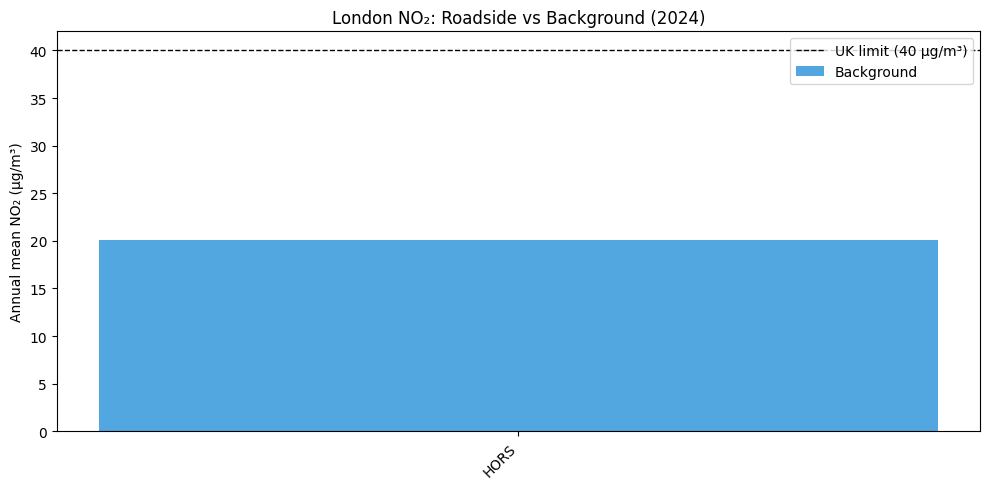

In [8]:
# Bar chart: annual means by site, coloured by type
fig, ax = plt.subplots(figsize=(10, 5))
colours = {"Roadside": "#e74c3c", "Background": "#3498db"}

for category, group in stats.groupby("category"):
    ax.bar(group["site_code"], group["annual_mean"],
           label=category, color=colours[category], alpha=0.85)

ax.axhline(40, color="black", linestyle="--", linewidth=1, label="UK limit (40 \u00b5g/m\u00b3)")
ax.set_ylabel("Annual mean NO\u2082 (\u00b5g/m\u00b3)")
ax.set_title("London NO\u2082: Roadside vs Background (2024)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Diurnal Profiles

The diurnal profile reveals the traffic rush-hour signature. Roadside sites
should show pronounced morning and evening peaks; background sites should be flatter.

We split into two DataFrames and plot each with `viz.plot_diurnal()`.

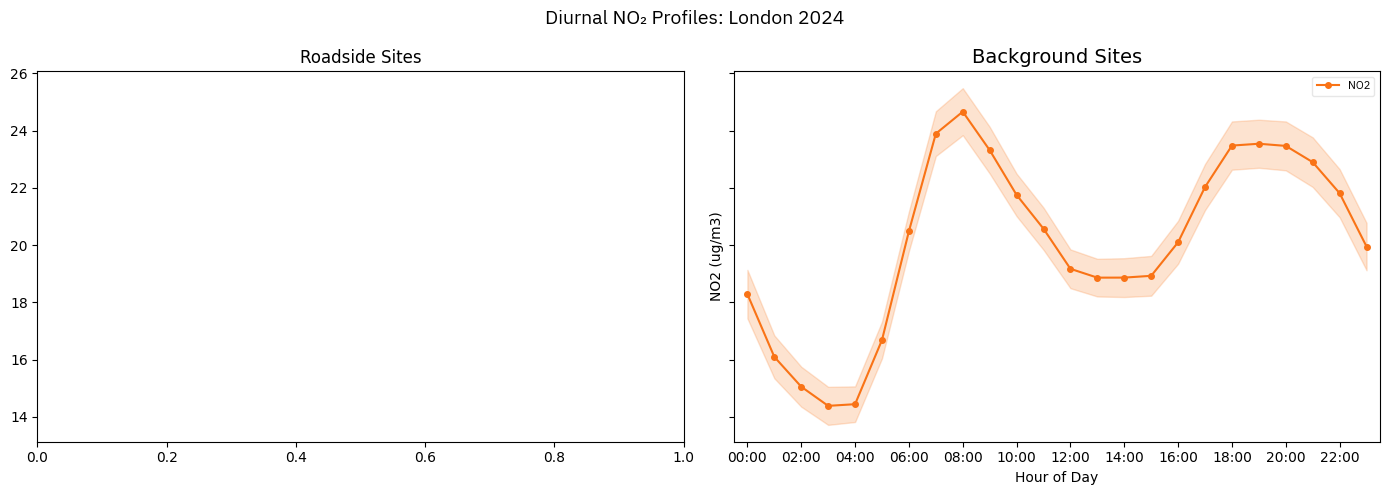

In [9]:
# Split data by site type
roadside_data = no2[no2["site_code"].isin(selected_traffic)]
background_data = no2[no2["site_code"].isin(selected_background)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

if not roadside_data.empty:
    viz.plot_diurnal(roadside_data, pollutants=["NO2"], ax=axes[0])
axes[0].set_title("Roadside Sites")

if not background_data.empty:
    viz.plot_diurnal(background_data, pollutants=["NO2"], ax=axes[1])
axes[1].set_title("Background Sites")

fig.suptitle("Diurnal NO\u2082 Profiles: London 2024", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Weekly Patterns

Weekday vs weekend differences highlight the traffic contribution.
Roadside sites typically show a larger weekday-weekend contrast.

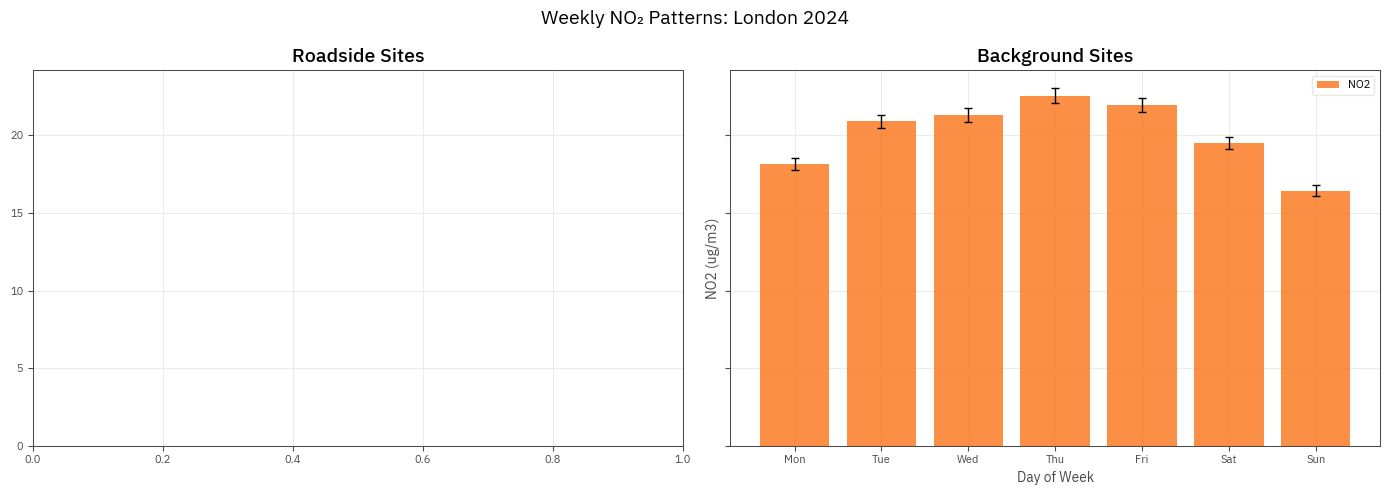

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

if not roadside_data.empty:
    viz.plot_weekly(roadside_data, pollutants=["NO2"], ax=axes[0])
axes[0].set_title("Roadside Sites")

if not background_data.empty:
    viz.plot_weekly(background_data, pollutants=["NO2"], ax=axes[1])
axes[1].set_title("Background Sites")

fig.suptitle("Weekly NO\u2082 Patterns: London 2024", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Full Time Variation (4-panel)

`plot_time_variation()` produces a 2\u00d72 panel showing diurnal, weekly, monthly,
and hour-of-day \u00d7 day-of-week patterns in one figure \u2014 equivalent to
R openair's `timeVariation()`.

In [11]:
# Full time variation for a single roadside site
if selected_traffic:
    site_code = selected_traffic[0]
    single_site = no2[no2['site_code'] == site_code]

    if not single_site.empty and 'NO2' in single_site['measurand'].values:
        fig = viz.plot_time_variation(
            single_site,
            pollutant='NO2',
            title=f"NO\u2082 Time Variation \u2014 {site_code} (Roadside)",
        )
        plt.show()
    else:
        print(f"No NO2 data available for {site_code}.")
else:
    print("No roadside sites available for time variation plot.")


No NO2 data available for LOFS.


## 7. Roadside Increment

The roadside increment is the difference between roadside and background
concentrations, representing the local traffic contribution. We use
`metrics.time_average()` to compute daily means, then calculate the increment.

In [12]:
# Daily means using time_average (composable with other metrics)
if roadside_data.empty or background_data.empty:
    print("Insufficient data for roadside increment calculation.")
    combined = pd.DataFrame(columns=["roadside", "background", "increment"])
else:
    daily_roadside = metrics.time_average(roadside_data, freq="D")
    daily_background = metrics.time_average(background_data, freq="D")

    # Average across sites for each category
    roadside_mean = (
        daily_roadside[daily_roadside["measurand"] == "NO2"]
        .groupby("date_time")["value"]
        .mean()
    )
    background_mean = (
        daily_background[daily_background["measurand"] == "NO2"]
        .groupby("date_time")["value"]
        .mean()
    )

    # Align and compute increment
    combined = pd.DataFrame({
        "roadside": roadside_mean,
        "background": background_mean,
    }).dropna()
    combined["increment"] = combined["roadside"] - combined["background"]

    print(f"Mean roadside increment: {combined['increment'].mean():.1f} \u00b5g/m\u00b3")
    print(f"As % of roadside total: {combined['increment'].mean() / combined['roadside'].mean() * 100:.0f}%")

Insufficient data for roadside increment calculation.


In [13]:
# Plot the increment over time
if not combined.empty:
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.fill_between(combined.index, 0, combined["background"],
                    alpha=0.4, color="#3498db", label="Background")
    ax.fill_between(combined.index, combined["background"], combined["roadside"],
                    alpha=0.4, color="#e74c3c", label="Roadside increment")
    ax.axhline(40, color="black", linestyle="--", linewidth=0.8, label="UK limit")

    ax.set_ylabel("Daily mean NO\u2082 (\u00b5g/m\u00b3)")
    ax.set_title("Roadside Increment: Traffic Contribution to London NO\u2082")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for increment plot.")

No data available for increment plot.


## Summary

This notebook demonstrated:

1. **Spatial site discovery** with `find_sites(near=..., radius_km=...)`
2. **Bulk download** of multi-site annual data in a single call
3. **Regulatory statistics** via `metrics.aq_stats()` with limit value comparison
4. **Temporal decomposition** using diurnal, weekly, and full time variation plots
5. **Composable analysis** with `metrics.time_average()` feeding into custom calculations

### Next steps
- Extend to multiple years for trend analysis (see `metrics.trend()`)
- Include PM\u2082.\u2085 for a multi-pollutant comparison
- Add SAQN/AQE sites for a wider UK picture (see Notebook 04)